In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import h5py
from tqdm import tqdm
from astropy.io import fits

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# Import autoreload for development:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
final_cube = fits.open('/dat/milic/atmos_cube_Na_wave.fits')[0].data
final_cube.shape

(9, 20, 301)

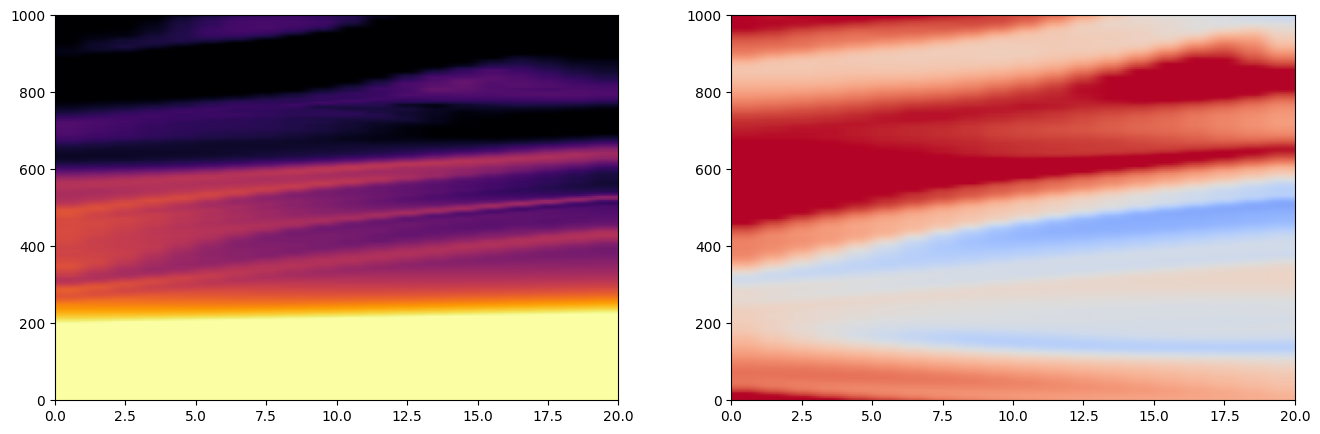

In [14]:
# Quick test of the data:
plt.figure(figsize=[16,5])
plt.subplot(121)
plt.imshow(final_cube[0,:,100:300].T, cmap='inferno', origin='lower', aspect='auto',vmin=4500,vmax=6000, extent=[0,20,0,1000])
plt.subplot(122)
plt.imshow(-final_cube[5,:,100:300].T/1E5, cmap='coolwarm', origin='lower', aspect='auto',vmin=-5,vmax=5, extent=[0,20,0,1000])

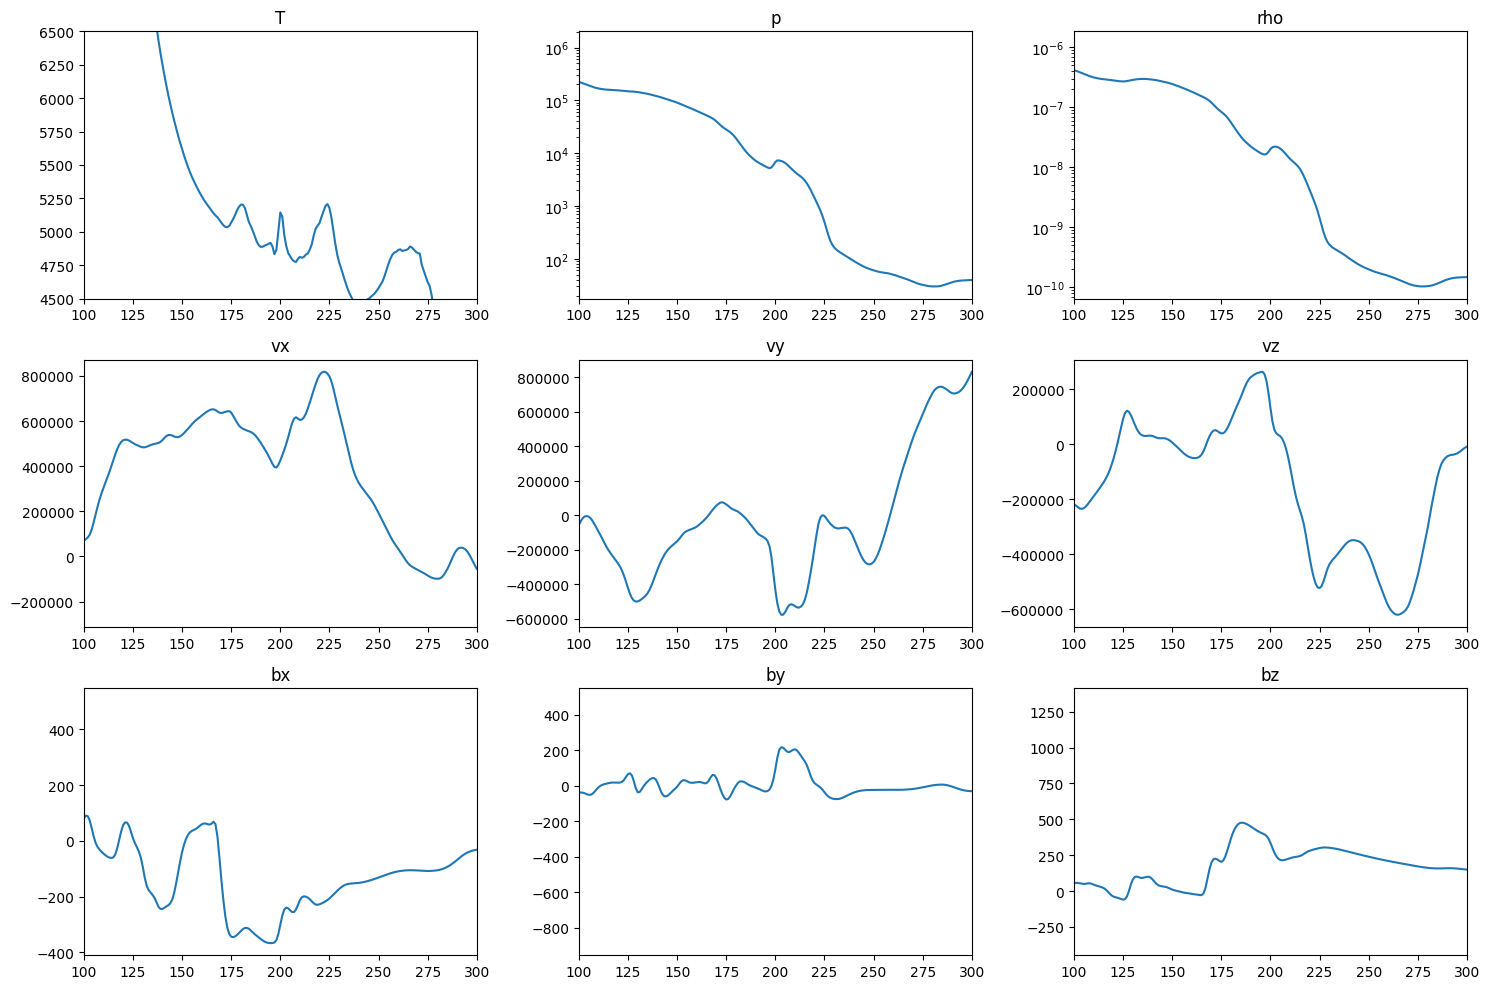

In [15]:
# Plot some 1D stratifications at a given time instance:
t_wave = 15
# Multiplot with 3 rows and 3 columns
fig, axs = plt.subplots(3, 3, figsize=(15, 10))
# Plot the depth variance of each variable at the given time instance
variables = ['T', 'p', 'rho', 'vx', 'vy', 'vz', 'bx', 'by', 'bz']
for i in range(3):
    for j in range(3):
        var_index = i*3 + j
        
        if (var_index == 1) or (var_index == 2):
            axs[i, j].semilogy(final_cube[var_index, t_wave, :].T)
        else:
        
            axs[i, j].plot(final_cube[var_index, t_wave, :].T)
        axs[i, j].set_title(variables[var_index])
        axs[i, j].set_xlim([100,300])
        

axs[0,0].set_ylim([4500, 6500])
plt.tight_layout()
plt.show()

In [38]:

ND = final_cube.shape[2]
z = np.arange(ND) * 5000.0 # m wave = np.linspace(588.8, 589.8, 1000) # Angstrom
lw_cube = np.ascontiguousarray(final_cube[:,:,::-1], dtype=np.float64)
z_scale = np.ascontiguousarray(z[::-1], dtype=np.float64)
wave = np.linspace(588.8, 589.8, 1001, dtype=np.float64)


In [39]:
from mini_lw_synth import synth_final

In [40]:
# synthesize Na line from a given atmosphere:

ctx, spectrum = synth_final(np.ascontiguousarray(z_scale), np.ascontiguousarray(lw_cube[:, t_wave, :]), wave, t_wave, lte=True)



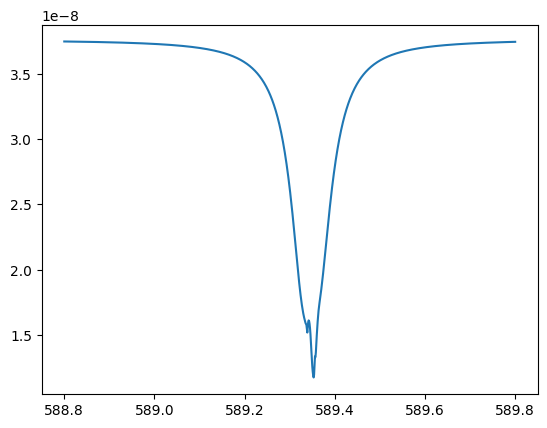

In [41]:
plt.plot(wave, spectrum[0,:])